# Laboratorio 03 — Modelos de Regresión Lineal
## InmoValor S.A. — Predicción del Precio de Venta de Viviendas

In [103]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, boxcox

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.feature_selection import RFE

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100,
})
sns.set_theme(style='whitegrid', palette='muted')

print("Librerías cargadas correctamente.")
print(f"   NumPy     {np.__version__}")
print(f"   Pandas    {pd.__version__}")


Librerías cargadas correctamente.
   NumPy     1.26.4
   Pandas    2.3.3


## Actividad 1 - Descarga del dataset


In [104]:
df = pd.read_csv('train.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"  → {df.shape[0]} observaciones (casas)")
print(f"  → {df.shape[1]} variables (columnas)")


Dimensiones del dataset: (1460, 81)
  → 1460 observaciones (casas)
  → 81 variables (columnas)


In [105]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [106]:
dtype_counts = df.dtypes.value_counts()
print("Tipos de datos:")
print(dtype_counts)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables numéricas : {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")


Tipos de datos:
object     43
int64      35
float64     3
Name: count, dtype: int64

Variables numéricas : 38
Variables categóricas: 43


In [107]:
df[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])


,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


In [108]:
df[cat_cols].describe().T


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## Actividades 2  - Análisis Exploratorio de Datos

### Actividad 2.1 Análisis de Valores Nulos

Identificamos 19 columnas con valores faltantes. Es fundamental entender **por qué** faltan estos datos antes de decidir cómo tratarlos:

- **Nulos estructurales (>80%):** `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%) y `MasVnrType` (59.7%) — en estos casos, `NA` **no significa dato faltante**, sino **ausencia de la característica** (sin piscina, sin callejón, sin cerca). Se rellenarán con la categoría `'None'` o `0`.
- **Nulos informativos (~5%):** Variables de garaje (`GarageYrBlt`, `GarageCond`, etc.) — la casa no tiene garaje. Mismo tratamiento.
- **Nulos aleatorios (<20%):** `LotFrontage` (17.7%) — dato genuinamente faltante, se imputa con la mediana por vecindario para preservar la variabilidad geográfica.


In [109]:
# Porcentaje de valores nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ['Variable', 'Porcentaje_Nulo']
null_df['Cantidad'] = df[null_df['Variable']].isnull().sum().values

print(f"Columnas con valores nulos: {len(null_df)}")
print(null_df.to_string(index=False))


Columnas con valores nulos: 19
    Variable  Porcentaje_Nulo  Cantidad
      PoolQC        99.520548      1453
 MiscFeature        96.301370      1406
       Alley        93.767123      1369
       Fence        80.753425      1179
  MasVnrType        59.726027       872
 FireplaceQu        47.260274       690
 LotFrontage        17.739726       259
 GarageYrBlt         5.547945        81
  GarageCond         5.547945        81
  GarageType         5.547945        81
GarageFinish         5.547945        81
  GarageQual         5.547945        81
BsmtFinType2         2.602740        38
BsmtExposure         2.602740        38
    BsmtQual         2.534247        37
    BsmtCond         2.534247        37
BsmtFinType1         2.534247        37
  MasVnrArea         0.547945         8
  Electrical         0.068493         1


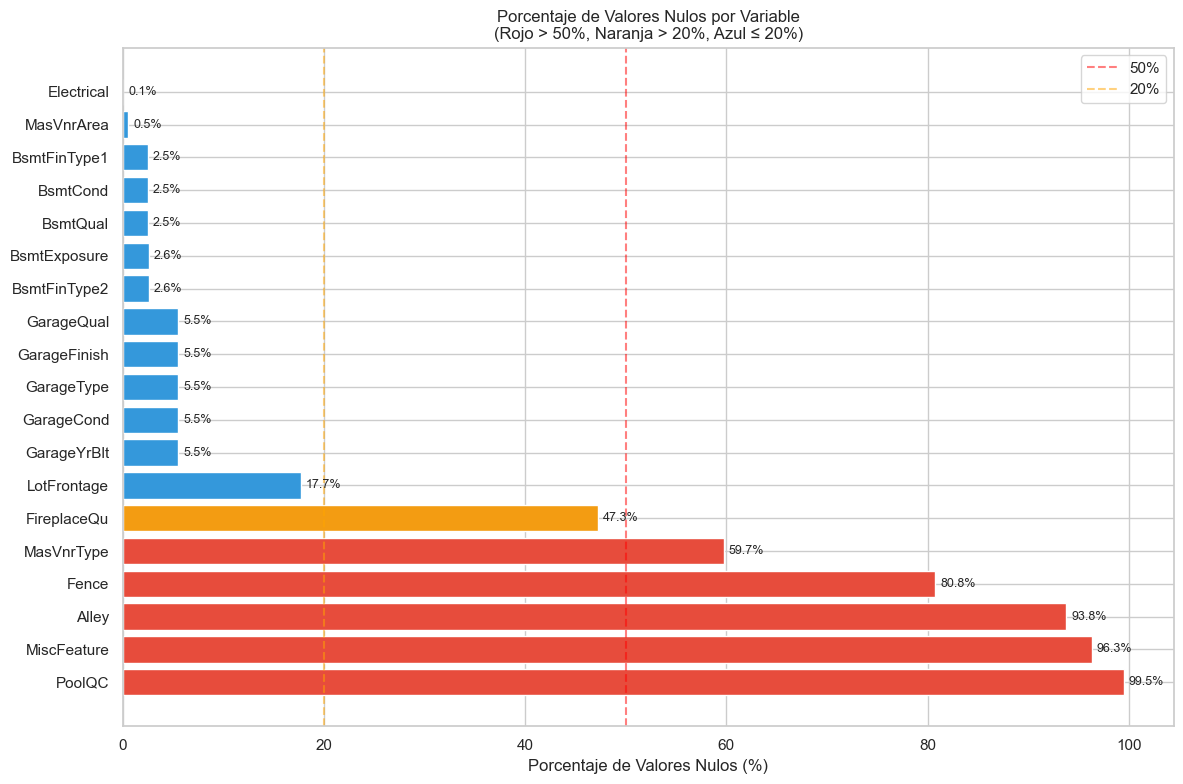

In [110]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db'
          for x in null_df['Porcentaje_Nulo']]
bars = ax.barh(null_df['Variable'], null_df['Porcentaje_Nulo'], color=colors)
ax.set_xlabel('Porcentaje de Valores Nulos (%)')
ax.set_title('Porcentaje de Valores Nulos por Variable\n(Rojo > 50%, Naranja > 20%, Azul ≤ 20%)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%')
ax.legend()
for bar, val in zip(bars, null_df['Porcentaje_Nulo']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 2.2 Análisis de la Variable Respuesta: `SalePrice`

Antes de modelar, debemos entender la distribución de la variable que queremos predecir. Si `SalePrice` no es aproximadamente normal, los supuestos de la regresión lineal pueden verse afectados.


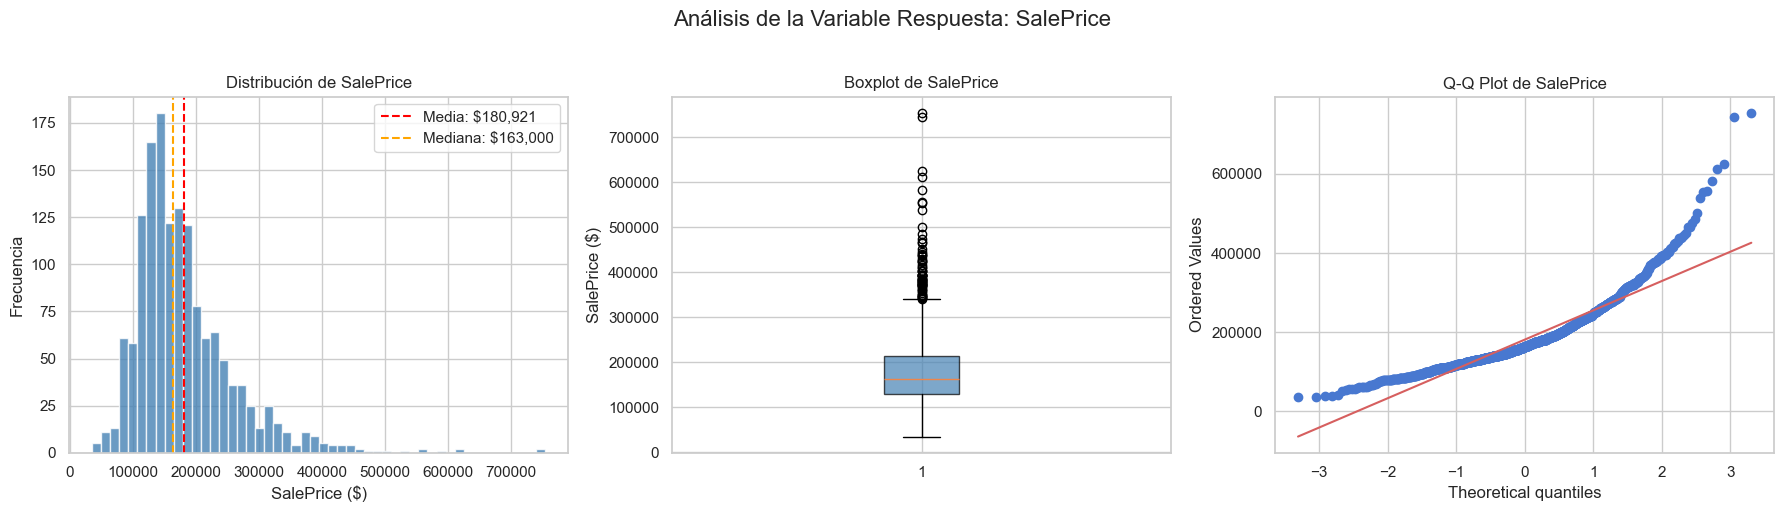

Asimetría (skewness): 1.8829
Curtosis (kurtosis) : 6.5363
Shapiro-Wilk (n≤5000): stat=0.8697, p-value=0.000000

→ NO sigue distribución normal (p < 0.05)


In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Media: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["SalePrice"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('SalePrice ($)')

# Q-Q Plot
stats.probplot(df['SalePrice'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot de SalePrice')

plt.suptitle('Análisis de la Variable Respuesta: SalePrice', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas clave
skew = df['SalePrice'].skew()
kurt = df['SalePrice'].kurtosis()
stat_sw, p_sw = shapiro(df['SalePrice'].sample(min(5000, len(df)), random_state=RANDOM_STATE))
print(f"Asimetría (skewness): {skew:.4f}")
print(f"Curtosis (kurtosis) : {kurt:.4f}")
print(f"Shapiro-Wilk (n≤5000): stat={stat_sw:.4f}, p-value={p_sw:.6f}")
print(f"\n→ {'NO sigue distribución normal (p < 0.05)' if p_sw < 0.05 else 'Posible distribución normal (p ≥ 0.05)'}")


### 2.3 Prueba de Normalidad y Transformación de `SalePrice`

**Resultados del test Shapiro-Wilk:**
- `SalePrice` original: asimetría = **1.88**, p-value ≈ 0 → **rechazamos normalidad**
- `log1p(SalePrice)`: asimetría = **0.12** → distribución casi simétrica

La transformación logarítmica reduce drásticamente la asimetría. Esto es importante porque los supuestos de regresión lineal asumen que los residuos (no necesariamente la variable respuesta) son normales. Con `SalePrice` muy sesgado, los residuos también tenderán a ser asimétricos. Los modelos de esta práctica trabajan con `SalePrice` en escala original para mantener interpretabilidad directa en dólares, pero se documenta esta transformación como alternativa de mejora.


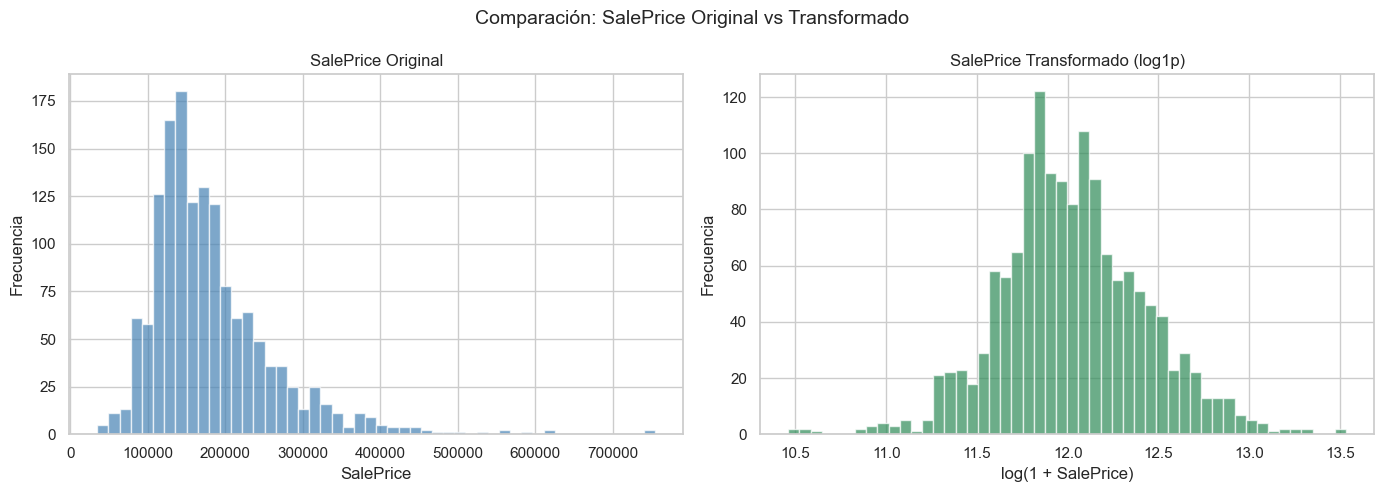

Después de transformación log:
  Asimetría: 0.1213  (original: 1.8829)
  Shapiro-Wilk: p = 0.000000

→ La transformación logarítmica reduce la asimetría significativamente,
   mejorando el cumplimiento de supuestos de normalidad.


In [112]:
# Transformación logarítmica
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original vs Log
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.7, label='Original')
axes[0].set_title('SalePrice Original')
axes[0].set_xlabel('SalePrice')

axes[1].hist(df['SalePrice_log'], bins=50, color='seagreen', edgecolor='white', alpha=0.7, label='log(1+SalePrice)')
axes[1].set_title('SalePrice Transformado (log1p)')
axes[1].set_xlabel('log(1 + SalePrice)')

for ax in axes:
    ax.set_ylabel('Frecuencia')

plt.suptitle('Comparación: SalePrice Original vs Transformado', fontsize=14)
plt.tight_layout()
plt.show()

# Prueba de normalidad en log
stat_log, p_log = shapiro(df['SalePrice_log'].sample(min(5000, len(df)), random_state=RANDOM_STATE))
skew_log = df['SalePrice_log'].skew()
print(f"Después de transformación log:")
print(f"  Asimetría: {skew_log:.4f}  (original: {df['SalePrice'].skew():.4f})")
print(f"  Shapiro-Wilk: p = {p_log:.6f}")
print("\n→ La transformación logarítmica reduce la asimetría significativamente,")
print("   mejorando el cumplimiento de supuestos de normalidad.")


### 2.4 Matriz de Correlaciones

**Hallazgos clave:**

| Variable | Correlación con SalePrice | Interpretación |
|---|---|---|
| `OverallQual` | **0.791** | La calidad general es el predictor más potente |
| `GrLivArea` | 0.709 | A mayor área habitable, mayor precio |
| `GarageCars` | 0.640 | Capacidad del garaje refleja nivel socioeconómico |
| `TotalBsmtSF` | 0.614 | Sótano grande = casa grande y más cara |
| `YearBuilt` | 0.523 | Casas más nuevas son más caras |
| `EnclosedPorch` | -0.129 | Porches cerrados se asocian a propiedades más antiguas/baratas |

**Conclusión:** Existe un grupo de variables relacionadas con tamaño y calidad que dominan la predicción de precios. La alta correlación entre varias de ellas (p.ej. `GrLivArea`, `1stFlrSF`, `TotalBsmtSF`) anticipa **multicolinealidad** en el modelo múltiple.


In [113]:
# Correlaciones con SalePrice
corr_with_target = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Top 15 variables con mayor correlación positiva con SalePrice:")
print(corr_with_target.head(15).to_string())
print("\nTop 5 variables con mayor correlación negativa:")
print(corr_with_target.tail(5).to_string())


Top 15 variables con mayor correlación positiva con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

Top 5 variables con mayor correlación negativa:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


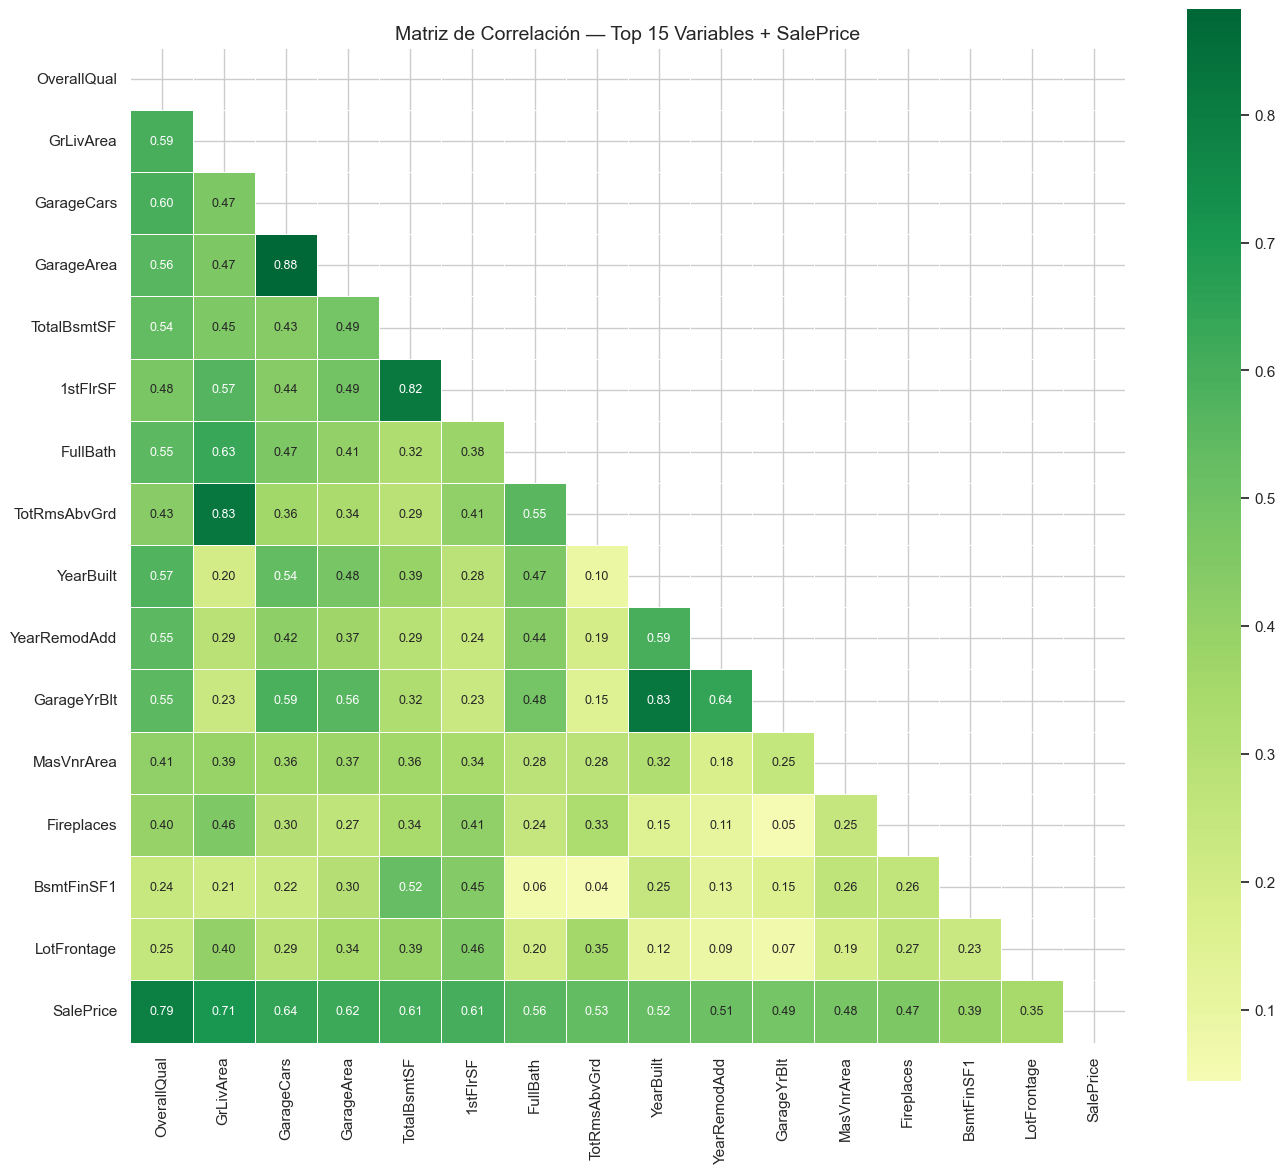

In [114]:
# Heatmap de las 15 variables más correlacionadas
top_corr_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
top_corr_cols.append('SalePrice')

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlación — Top 15 Variables + SalePrice', fontsize=14)
plt.tight_layout()
plt.show()


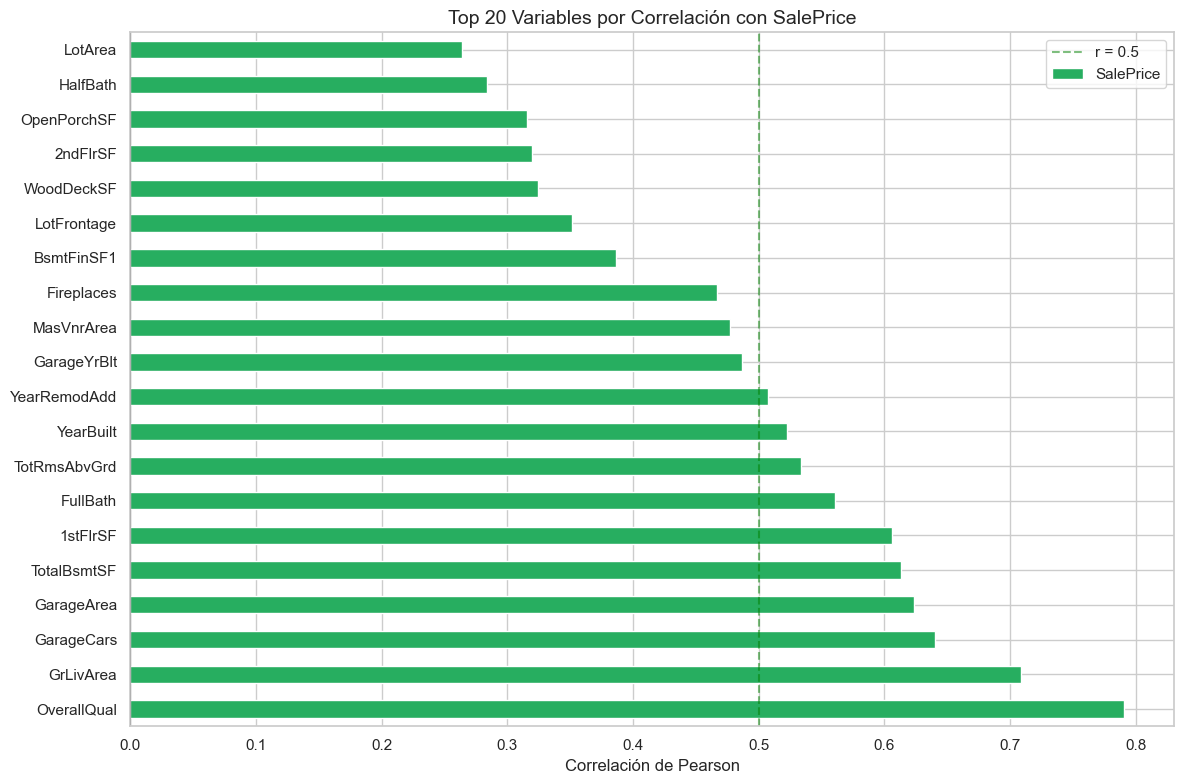

In [115]:
# Gráfico de barras de correlaciones
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in corr_with_target.head(20)]
corr_with_target.head(20).plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Variables por Correlación con SalePrice', fontsize=14)
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='r = 0.5')
ax.legend()
plt.tight_layout()
plt.show()


### 2.5 Diagramas de Dispersión — Variables Numéricas Clave vs SalePrice

Los diagramas de dispersión confirman las correlaciones calculadas y revelan patrones adicionales:
- La relación entre `OverallQual` y `SalePrice` es casi escalonada (variable discreta 1-10), con notable dispersión en calidades altas.
- `GrLivArea` muestra una relación lineal limpia, con algunos **outliers** (casas muy grandes con precio sorprendentemente bajo — posiblemente ventas atípicas).
- Variables como `MasVnrArea` muestran muchos ceros (casas sin mampostería), lo que crea una distribución bimodal en el eje X.


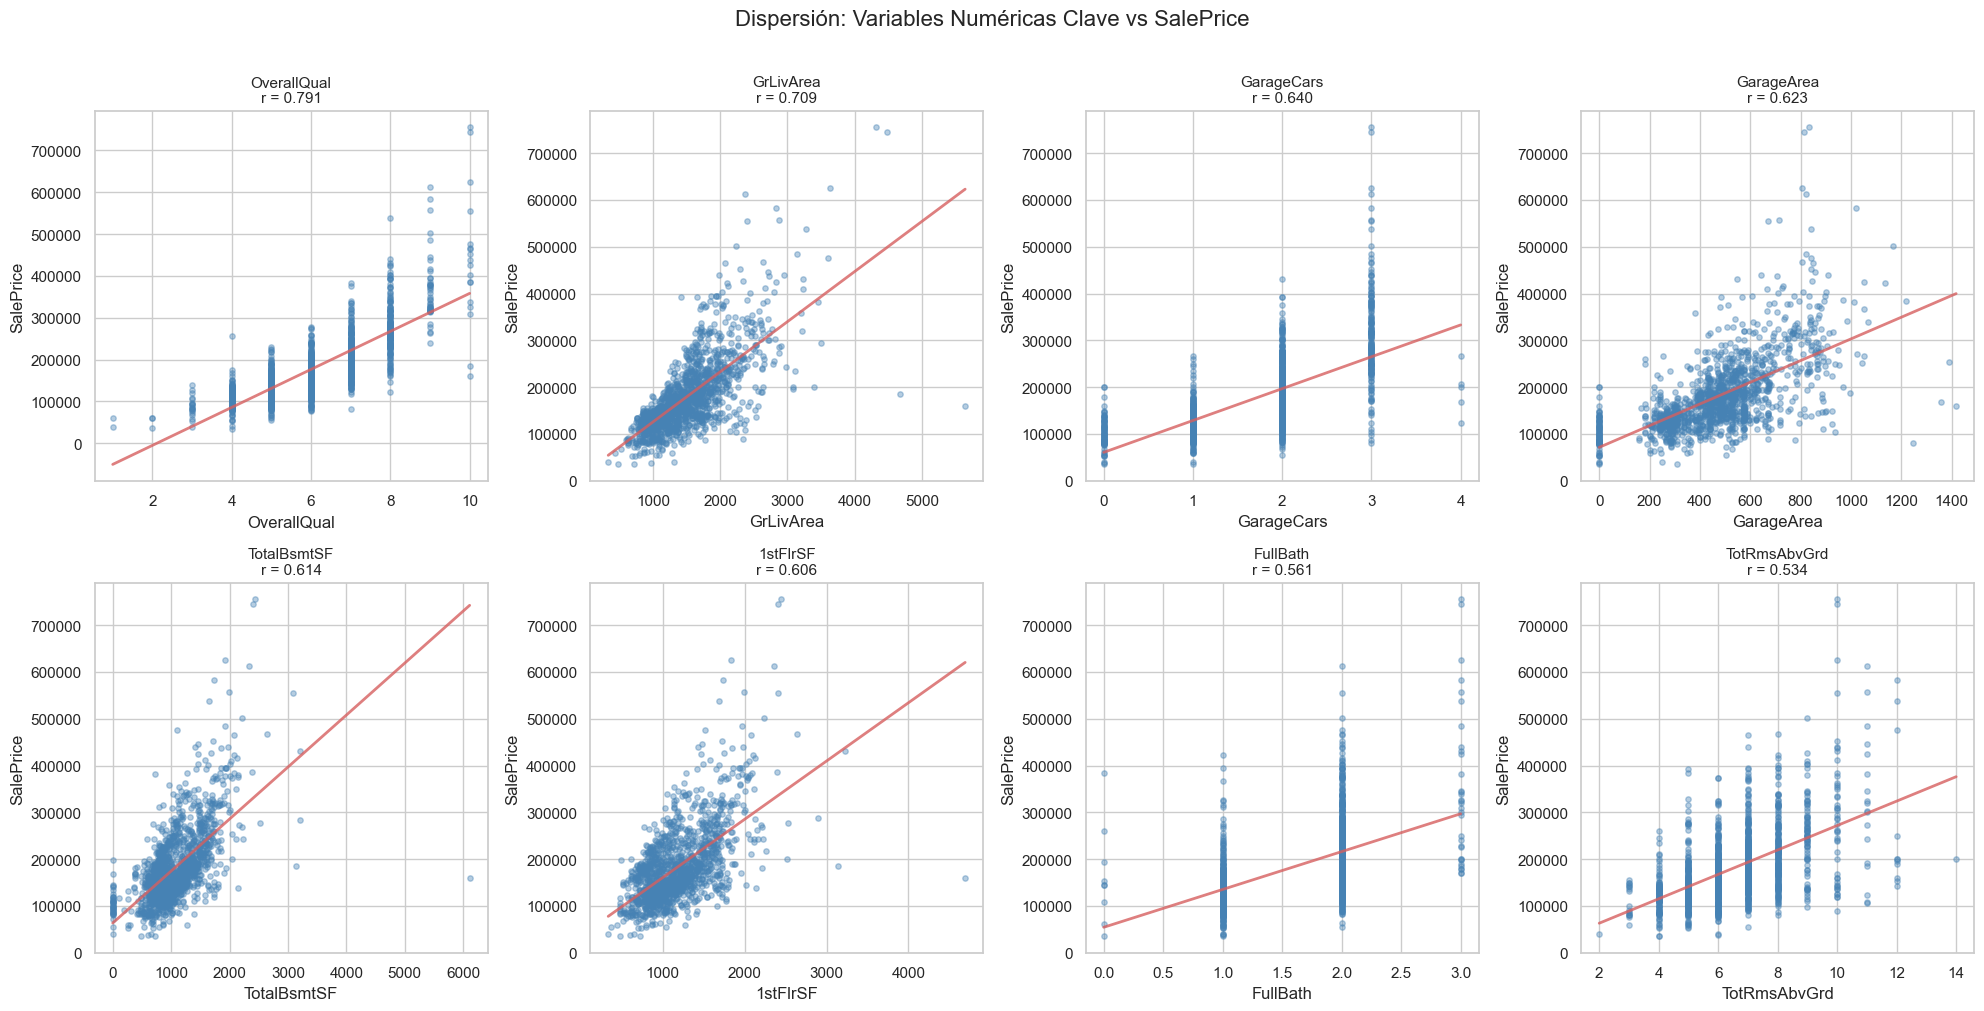

In [116]:
top_num_vars = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(top_num_vars):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.4, s=15, color='steelblue')
    # Línea de tendencia
    z = np.polyfit(df[col].fillna(df[col].median()), df['SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.8)
    r = df[[col, 'SalePrice']].corr().iloc[0, 1]
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

plt.suptitle('Dispersión: Variables Numéricas Clave vs SalePrice', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### 2.6 Variables Categóricas vs SalePrice

Los boxplots revelan diferencias de precio muy marcadas según categorías:
- **`OverallQual`**: Diferencia de más de $300,000 entre calidad 1 y 10. Es la variable más discriminante.
- **`Neighborhood`**: El vecindario explica diferencias sustanciales de precio (NoRidge y NridgHt son los más caros; MeadowV y IDOTRR los más baratos). Esto justifica incluirlo en el modelo mediante OHE.
- **`ExterQual` / `KitchenQual`**: Calidad exterior y de cocina muestran una progresión clara y monótona con el precio — serán codificadas ordinalmente.
- **`Foundation`**: Cimentación de hormigón (`PConc`) se asocia a casas más modernas y costosas.


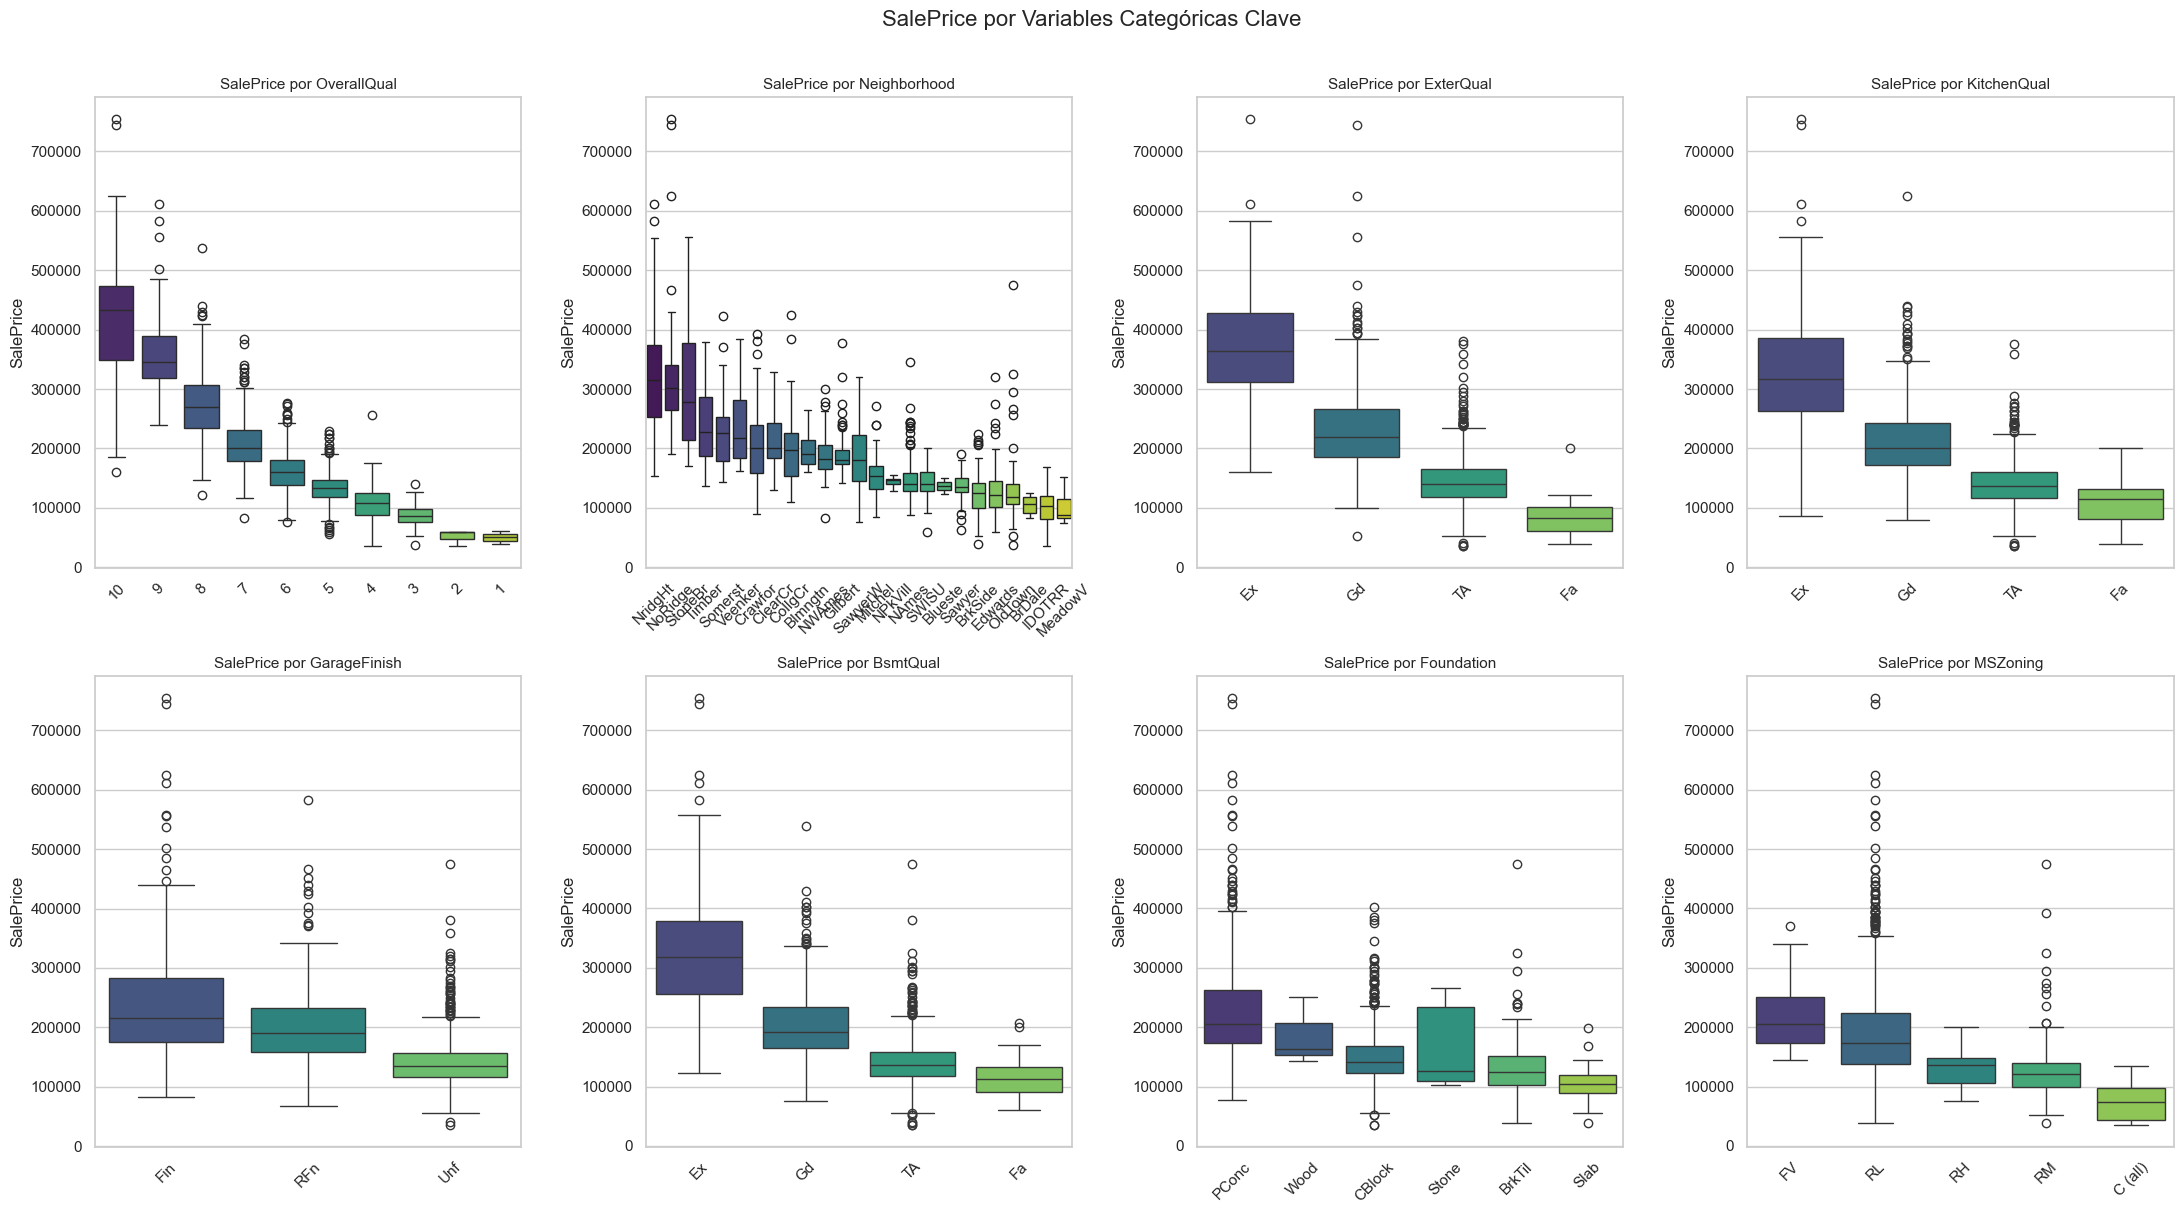

In [117]:
key_cat_vars = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual',
                'GarageFinish', 'BsmtQual', 'Foundation', 'MSZoning']

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(key_cat_vars):
    order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', ax=axes[i], order=order,
                palette='viridis')
    axes[i].set_title(f'SalePrice por {col}', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle('SalePrice por Variables Categóricas Clave', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### 2.7 Distribuciones de Variables Numéricas Clave

La mayoría de variables numéricas presentan asimetría positiva (cola derecha larga), típica de datos inmobiliarios:
- `LotArea` y `GrLivArea` tienen outliers extremos que podrían influir desproporcionadamente en el modelo.
- `YearBuilt` muestra una concentración de construcciones en los años 1950-2010, con un pico en 2000-2005 (boom inmobiliario).
- Variables de porches y terrazas (`OpenPorchSF`, `WoodDeckSF`) tienen muchos ceros — la mayoría de casas no tienen o tienen áreas pequeñas.


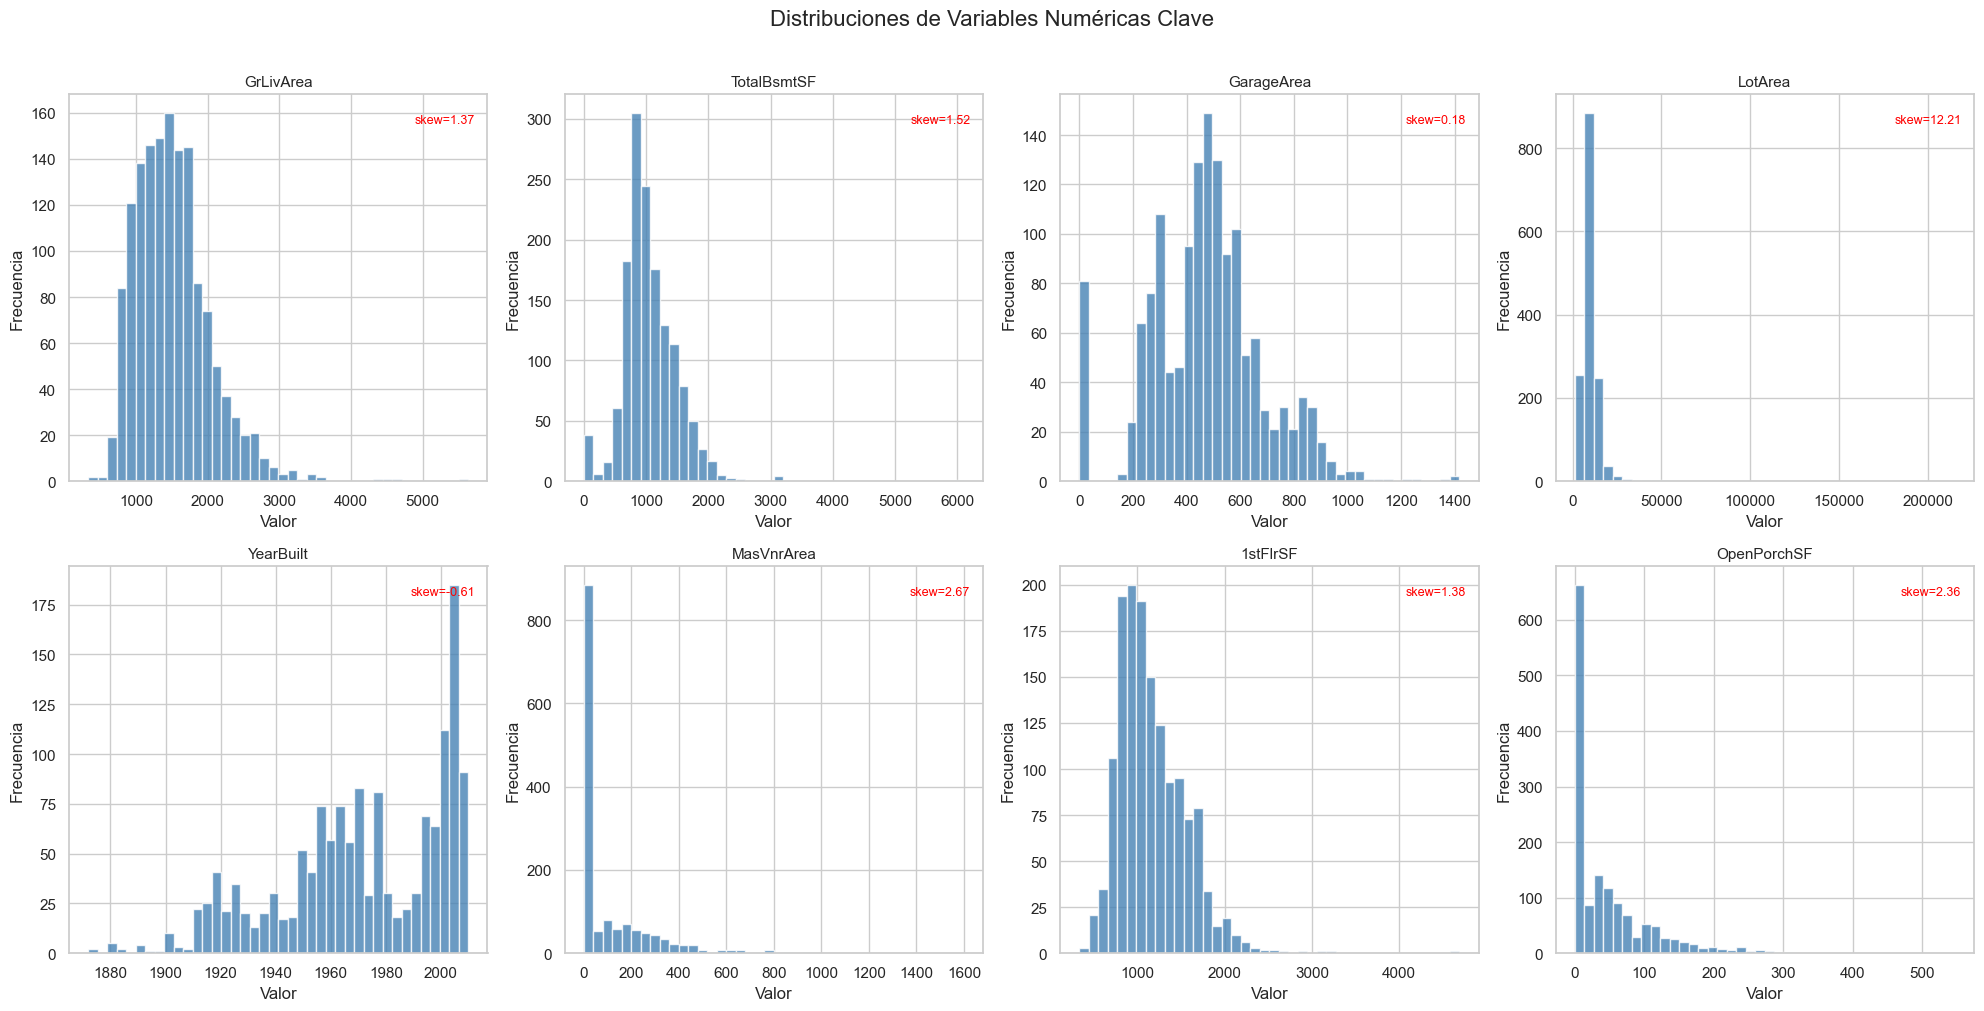

In [118]:
key_num = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea',
           'YearBuilt', 'MasVnrArea', '1stFlrSF', 'OpenPorchSF']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    skew = data.skew()
    axes[i].text(0.97, 0.95, f'skew={skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='red')

plt.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Actividad 3 - Análisis de Grupos  (K-Means Clustering)

**Objetivo:** Segmentar las propiedades en grupos homogéneos para descubrir patrones naturales en el mercado inmobiliario de Ames, Iowa. Usamos K-Means sobre 6 variables clave: `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `GarageArea`, `YearBuilt` y `SalePrice`.

**Selección de k:** Se aplicó el método del codo, que sugiere **k=4** como punto de inflexión óptimo.


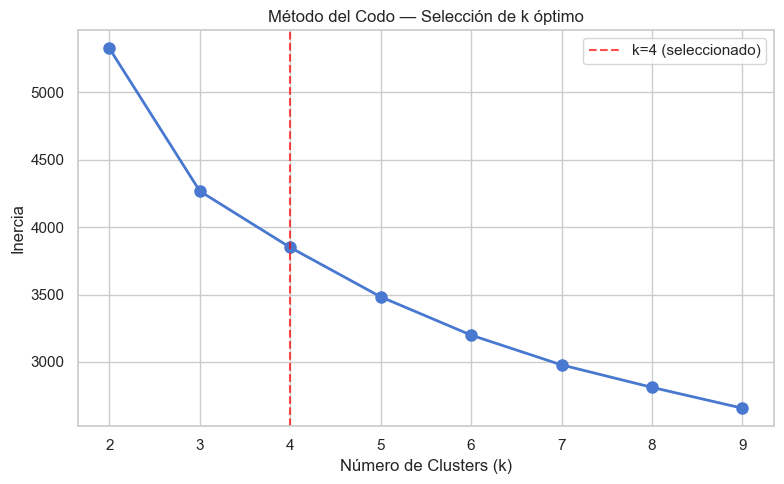

In [119]:
# Variables para clustering (las más descriptivas y numéricas)
cluster_vars = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
                'YearBuilt', 'SalePrice']

# Imputación simple para clustering
df_cluster = df[cluster_vars].copy()
df_cluster.fillna(df_cluster.median(), inplace=True)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Método del codo para elegir k
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Método del Codo — Selección de k óptimo')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (seleccionado)')
ax.legend()
plt.tight_layout()
plt.show()


In [120]:
# Ajustar K-Means con k=4
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Descripción de cada cluster
cluster_summary = df.groupby('Cluster')[cluster_vars].mean().round(0)
cluster_summary['Count'] = df.groupby('Cluster').size()
cluster_summary['Pct_%'] = (cluster_summary['Count'] / len(df) * 100).round(1)
print("Resumen de Clusters:")
print(cluster_summary.to_string())


Resumen de Clusters:
         OverallQual  GrLivArea  TotalBsmtSF  GarageArea  YearBuilt  SalePrice  Count  Pct_%
Cluster                                                                                     
0                7.0     1587.0       1073.0       513.0     1998.0   198915.0    422   28.9
1                6.0     1493.0       1041.0       506.0     1956.0   157538.0    408   27.9
2                8.0     2199.0       1646.0       765.0     1997.0   322178.0    211   14.5
3                5.0     1122.0        761.0       252.0     1946.0   114434.0    419   28.7


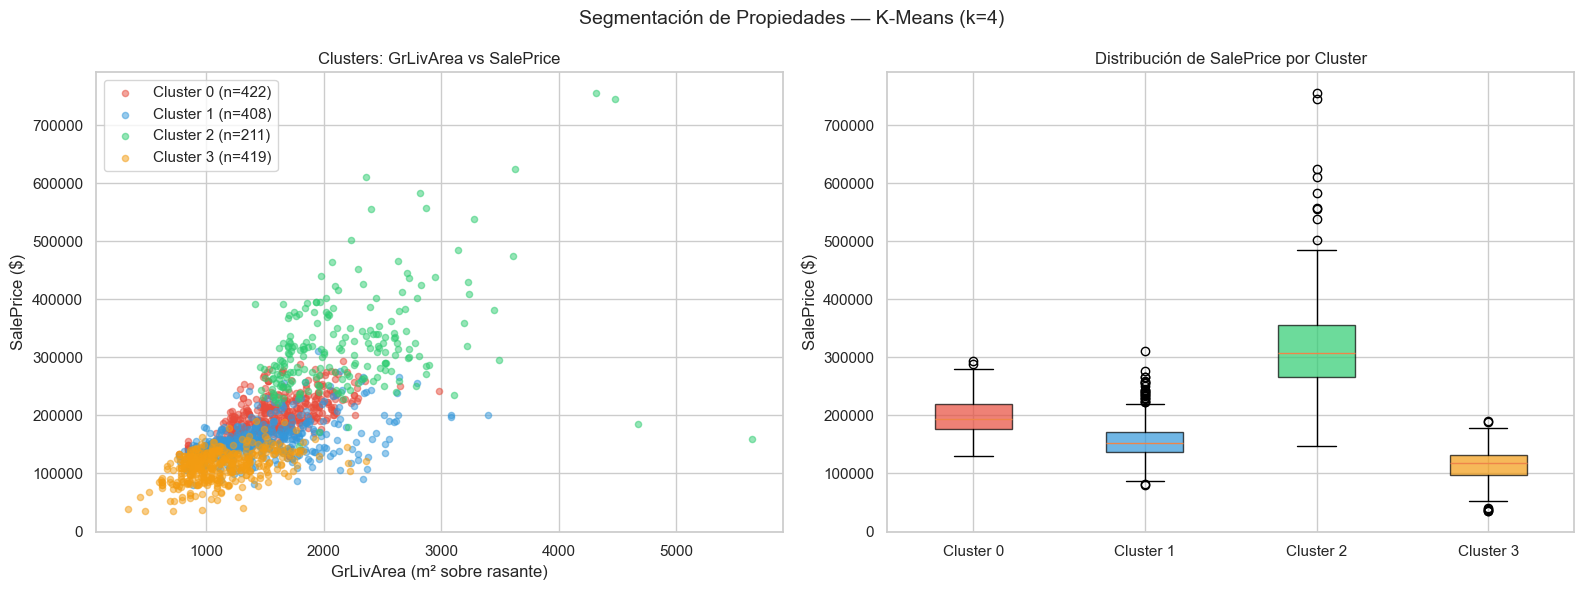

In [121]:
# Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}

for cluster_id in range(K_OPTIMAL):
    mask = df['Cluster'] == cluster_id
    axes[0].scatter(df.loc[mask, 'GrLivArea'], df.loc[mask, 'SalePrice'],
                    c=colors[cluster_id], alpha=0.5, s=20,
                    label=f'Cluster {cluster_id} (n={mask.sum()})')

axes[0].set_xlabel('GrLivArea (m² sobre rasante)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Clusters: GrLivArea vs SalePrice')
axes[0].legend()

# Boxplot SalePrice por cluster
cluster_data = [df[df['Cluster'] == c]['SalePrice'].values for c in range(K_OPTIMAL)]
bp = axes[1].boxplot(cluster_data, patch_artist=True, labels=[f'Cluster {i}' for i in range(K_OPTIMAL)])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribución de SalePrice por Cluster')
axes[1].set_ylabel('SalePrice ($)')

plt.suptitle('Segmentación de Propiedades — K-Means (k=4)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Descripción cualitativa de los clusters
for c in range(K_OPTIMAL):
    subset = df[df['Cluster'] == c]
    print(f"\nCluster {c} ({len(subset)} propiedades, {len(subset)/len(df)*100:.1f}%):")
    print(f"   SalePrice promedio : ${subset['SalePrice'].mean():,.0f}")
    print(f"   Calidad promedio   : {subset['OverallQual'].mean():.1f}/10")
    print(f"   GrLivArea promedio : {subset['GrLivArea'].mean():.0f} ft²")
    print(f"   Año construcción   : {subset['YearBuilt'].mean():.0f}")
    print(f"   GarageArea promedio: {subset['GarageArea'].mean():.0f} ft²")



Cluster 0 (422 propiedades, 28.9%):
   SalePrice promedio : $198,915
   Calidad promedio   : 6.8/10
   GrLivArea promedio : 1587 ft²
   Año construcción   : 1998
   GarageArea promedio: 513 ft²

Cluster 1 (408 propiedades, 27.9%):
   SalePrice promedio : $157,538
   Calidad promedio   : 5.5/10
   GrLivArea promedio : 1493 ft²
   Año construcción   : 1956
   GarageArea promedio: 506 ft²

Cluster 2 (211 propiedades, 14.5%):
   SalePrice promedio : $322,178
   Calidad promedio   : 8.2/10
   GrLivArea promedio : 2199 ft²
   Año construcción   : 1997
   GarageArea promedio: 765 ft²

Cluster 3 (419 propiedades, 28.7%):
   SalePrice promedio : $114,434
   Calidad promedio   : 4.9/10
   GrLivArea promedio : 1122 ft²
   Año construcción   : 1946
   GarageArea promedio: 252 ft²
